In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

pd.plotting.register_matplotlib_converters()
%matplotlib inline


In [3]:
pd.set_option('display.max_columns', 500)
warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-whitegrid')

In [4]:
data = pd.read_csv(r'c:\Users\User\Downloads\insurance.csv', nrows=1000)
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
print(f'Shape of the data: {data.shape}')
print(f'There are {data.shape[0]} rows in the data.')

Shape of the data: (1000, 7)
There are 1000 rows in the data.


In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1000 non-null   int64  
 1   sex       1000 non-null   str    
 2   bmi       1000 non-null   float64
 3   children  1000 non-null   int64  
 4   smoker    1000 non-null   str    
 5   region    1000 non-null   str    
 6   charges   1000 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 54.8 KB


In [10]:

data.dtypes.unique()

array([dtype('int64'), <StringDtype(storage='python', na_value=nan)>,
       dtype('float64')], dtype=object)

In [11]:

data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [12]:
g = data.columns.to_series().groupby(data.dtypes.astype(str)).groups
g

{'float64': ['bmi', 'charges'], 'int64': ['age', 'children'], 'str': ['sex', 'smoker', 'region']}

In [13]:
dt = {k: v for k, v in g.items()}

In [14]:

sorted(data['children'].unique())

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

In [15]:
data.isnull().any()

age         False
sex         False
bmi         False
children    False
smoker      False
region      False
charges     False
dtype: bool

In [16]:
data.describe()

,age,bmi,children,charges
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,39.615000,30.86338,1.080000,13075.755883
std,14.153908,6.04744,1.198765,11985.924552
min,18.000000,15.96000,0.000000,1121.873900
25%,27.000000,26.60000,0.000000,4719.683425
50%,40.000000,30.59000,1.000000,9283.021300
75%,52.000000,35.11250,2.000000,15882.795438
max,64.000000,50.38000,5.000000,63770.428010


In [17]:

def summary(x):
    x_min = data[x].min()
    x_max = data[x].max()
    Q1 = data[x].quantile(0.25)
    Q2 = data[x].quantile(0.50)
    Q3 = data[x].quantile(0.75)
    print(f'5 Point Summary of {x.capitalize()} Attribute:\n'
          f'{x.capitalize()}(min) : {x_min}\n'
          f'Q1                    : {Q1}\n'
          f'Q2(Median)            : {Q2}\n'
          f'Q3                    : {Q3}\n'
          f'{x.capitalize()}(max) : {x_max}')

    fig = plt.figure(figsize=(16, 10))
    plt.subplots_adjust(hspace = 0.6)
    sns.set_palette('pastel')
    
    plt.subplot(221)
    ax1 = sns.distplot(data[x], color = 'r')
    plt.title(f'{x.capitalize()} Density Distribution')
    
    plt.subplot(222)
    ax2 = sns.violinplot(x = data[x], palette = 'Accent', split = True)
    plt.title(f'{x.capitalize()} Violinplot')
    
    plt.subplot(223)
    ax2 = sns.boxplot(x=data[x], palette = 'cool', width=0.7, linewidth=0.6)
    plt.title(f'{x.capitalize()} Boxplot')
    
    plt.subplot(224)
    ax3 = sns.kdeplot(data[x], cumulative=True)
    plt.title(f'{x.capitalize()} Cumulative Density Distribution')
    
    plt.show()

In [18]:

def box_plot(x = 'bmi'):
    def add_values(bp, ax):
       
        for element in ['whiskers', 'medians', 'caps']:
            for line in bp[element]:
              
                (x_l, y),(x_r, _) = line.get_xydata()
                
                if not np.isnan(y): 
                    x_line_center = x_l + (x_r - x_l)/2
                    y_line_center = y 
                    ax.text(x_line_center, y_line_center, 
                            '%.2f' % y, 
                            verticalalignment='center', 
                            fontsize=12, backgroundcolor="white")

    fig, axes = plt.subplots(1, figsize=(4, 8))

    red_diamond = dict(markerfacecolor='r', marker='D')

    bp_dict = data.boxplot(column = x, 
                             grid=True, 
                             figsize=(4, 8), 
                             ax=axes, 
                             vert = True, 
                             notch=False, 
                             widths = 0.7, 
                             showmeans = True, 
                             whis = 1.5,
                             flierprops = red_diamond,
                             boxprops= dict(linewidth=3.0, color='black'),
                             whiskerprops=dict(linewidth=3.0, color='black'),
                             return_type = 'dict')

    add_values(bp_dict, axes)

    plt.title(f'{x.capitalize()} Boxplot', fontsize=16)
    plt.ylabel(f'{x.capitalize()}', fontsize=14)
    plt.show()
    
    skew = data[x].skew()
    Q1 = data[x].quantile(0.25)
    Q3 = data[x].quantile(0.75)
    IQR = Q3 - Q1
    total_outlier_num = ((data[x] < (Q1 - 1.5 * IQR)) | (data[x] > (Q3 + 1.5 * IQR))).sum()
    print(f'Mean {x.capitalize()} = {data[x].mean()}')
    print(f'Median {x.capitalize()} = {data[x].median()}')
    print(f'Skewness of {x}: {skew}.')
    print(f'Total number of outliers in {x} distribution: {total_outlier_num}.')   

In [19]:
!pip install scipy


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


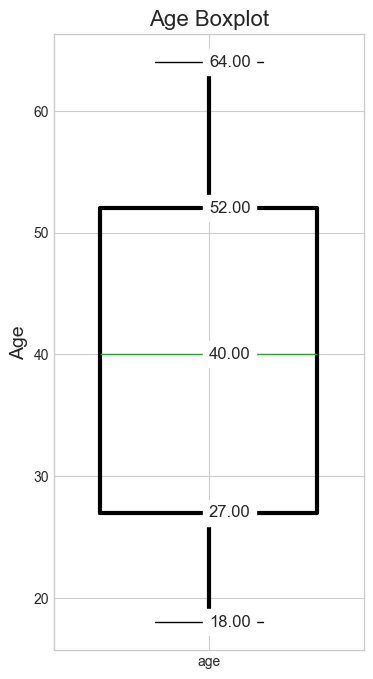

Mean Age = 39.615
Median Age = 40.0
Skewness of age: 0.026202878903998517.
Total number of outliers in age distribution: 0.


In [20]:
box_plot('age')

In [21]:

df = data[data['age'] == data['age'].max()]
print(df.head())
print()
print(f'Total number of insured people with the age of 64: {len(df)}.')

     age     sex    bmi  children smoker     region      charges
62    64    male  24.70         1     no  northwest  30166.61817
94    64  female  31.30         2    yes  southwest  47291.05500
199   64  female  39.33         0     no  northeast  14901.51670
328   64  female  33.80         1    yes  southwest  47928.03000
335   64    male  34.50         0     no  southwest  13822.80300

Total number of insured people with the age of 64: 19.


BMI Distribution:

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

def summary(x):
    plt.figure(figsize=(10,8))

    plt.subplot(221)
    sns.histplot(data[x])
    plt.title(f'{x.capitalize()} Histogram')

    plt.subplot(222)
    sns.boxplot(x=data[x])
    plt.title(f'{x.capitalize()} Boxplot')

    plt.subplot(223)
    sns.kdeplot(data[x])
    plt.title(f'{x.capitalize()} Density Plot')

    plt.subplot(224)
    sns.ecdfplot(data[x])   
    plt.title(f'{x.capitalize()} Cumulative Distribution')

    plt.show()

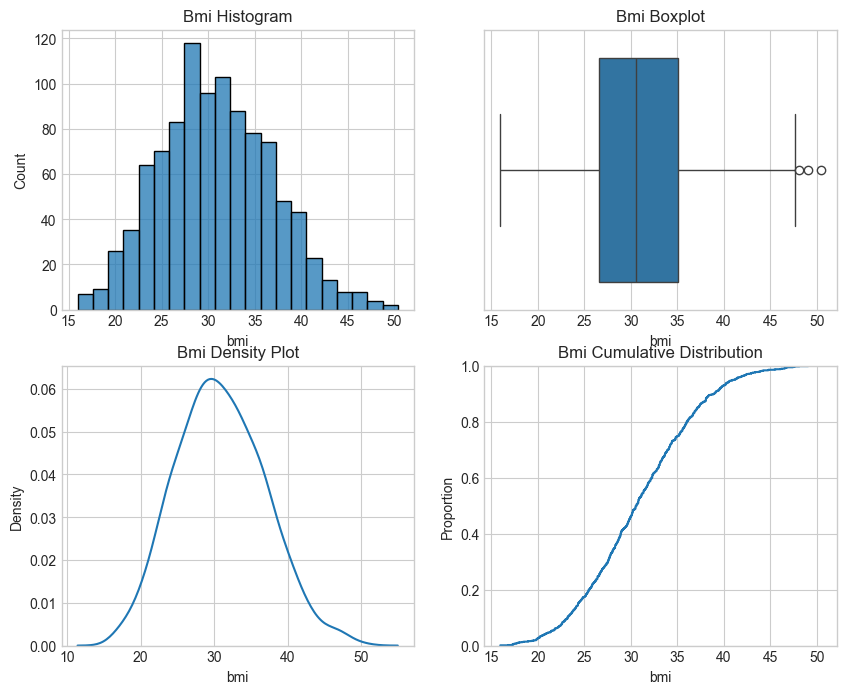

In [23]:
summary('bmi')

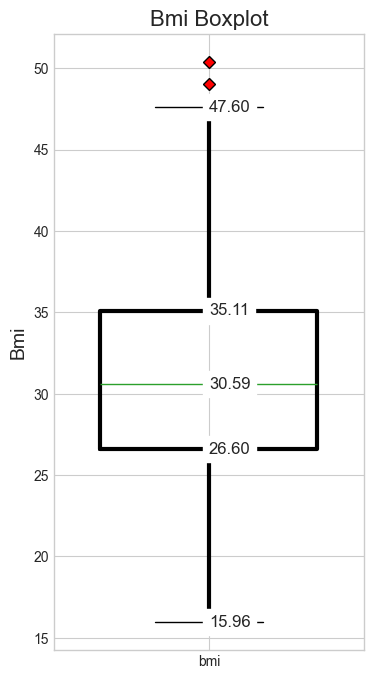

Mean Bmi = 30.86338
Median Bmi = 30.59
Skewness of bmi: 0.23400586055388986.
Total number of outliers in bmi distribution: 3.


In [24]:
box_plot('bmi')

In [25]:

data[data['bmi'] == data['bmi'].max()]

,age,sex,bmi,children,smoker,region,charges
847,23,male,50.38,1,no,southeast,2438.0552


In [26]:
data['charges'].mean(), data['charges'].median()

(np.float64(13075.755883299), np.float64(9283.0213))

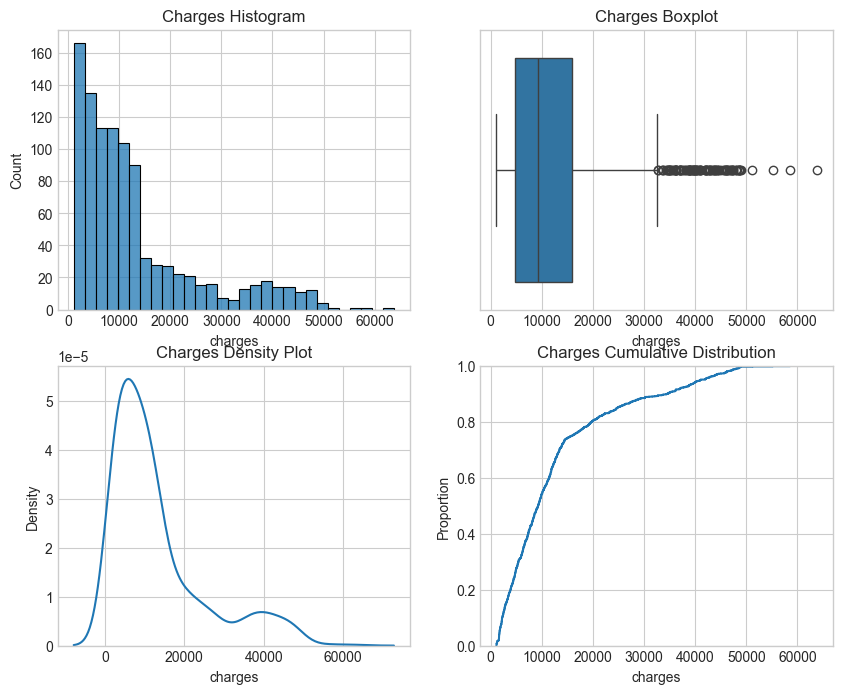

In [27]:
summary('charges')

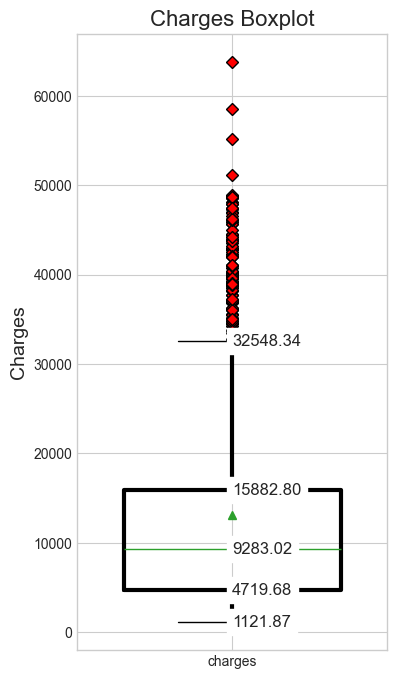

Mean Charges = 13075.755883299
Median Charges = 9283.0213
Skewness of charges: 1.53065288100353.
Total number of outliers in charges distribution: 108.


In [28]:
box_plot('charges')

In [29]:

data[data['charges'] == data['charges'].max()]

,age,sex,bmi,children,smoker,region,charges
543,54,female,47.41,0,yes,southeast,63770.42801


In [30]:

data[data['bmi'] == data['bmi'].max()]

,age,sex,bmi,children,smoker,region,charges
847,23,male,50.38,1,no,southeast,2438.0552


In [31]:
data['charges'].mean(), data['charges'].median()

(np.float64(13075.755883299), np.float64(9283.0213))


Distribution of categorical variables:  'sex', 'smoker', 'region' and 'children'.

In [32]:

def pie_chart(x = 'smoker'):
    
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(aspect="equal"))

    s = data.groupby(x).size()

    mydata_values = s.values.tolist()
    mydata_index = s.index.tolist()

    def func(pct, allvals):
        absolute = int(pct/100.*np.sum(allvals))
        return "{:.1f}%\n({:d})".format(pct, absolute)


    wedges, texts, autotexts = ax.pie(mydata_values, autopct=lambda pct: func(pct, mydata_values),
                                      textprops=dict(color="w"))

    ax.legend(wedges, mydata_index,
              title="Index",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1))

    plt.setp(autotexts, size=12, weight="bold")

    ax.set_title(f'{x.capitalize()} Piechart')

    plt.show()

<Axes: xlabel='sex', ylabel='count'>

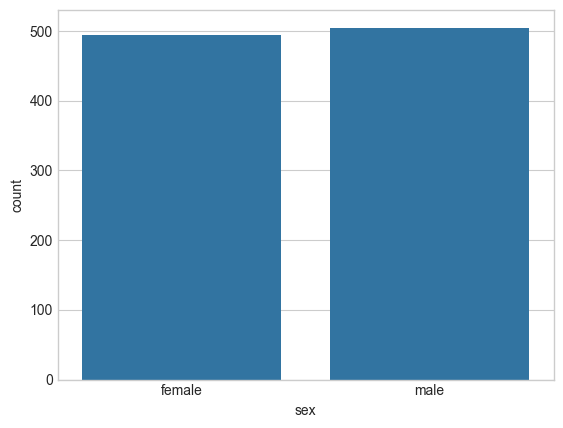

In [33]:
sns.countplot(x = 'sex', data = data)

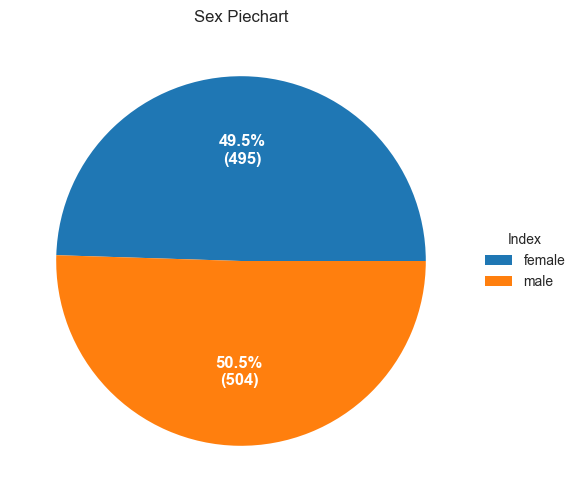

In [34]:
pie_chart('sex')

<Axes: xlabel='smoker', ylabel='count'>

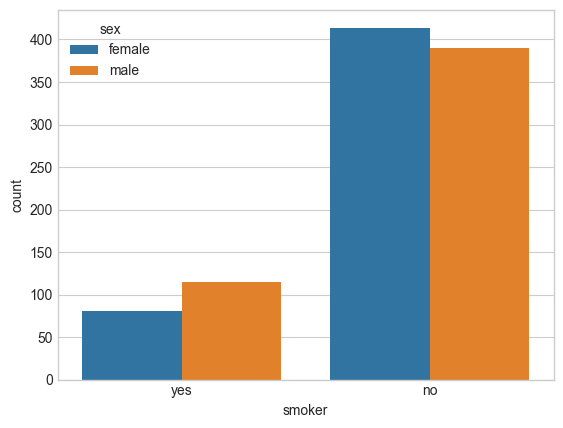

In [35]:
sns.countplot(x = 'smoker', hue = 'sex', data = data)

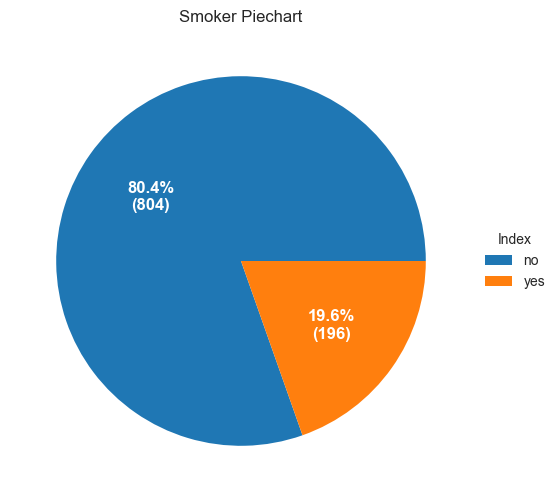

In [36]:
pie_chart('smoker')

In [37]:

data['charges'].groupby(data['smoker']).mean()

smoker
no      8435.581066
yes    32109.942377
Name: charges, dtype: float64

In [38]:
data.groupby(['smoker', 'sex']).agg('count')

age  bmi  children  region  charges
smoker sex                                        
no     female  414  414       414     414      414
       male    390  390       390     390      390
yes    female   81   81        81      81       81
       male    115  115       115     115      115

<Axes: xlabel='smoker', ylabel='charges'>

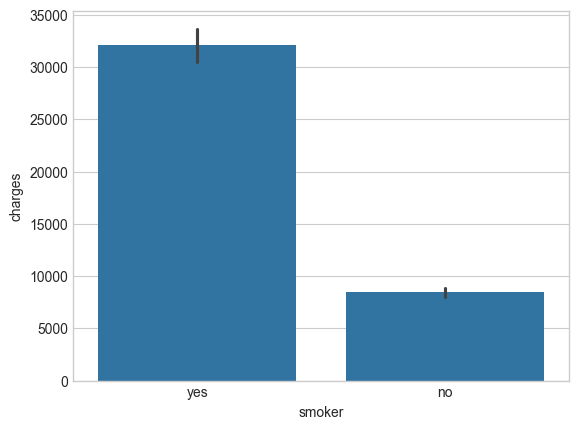

In [39]:

sns.barplot(x = "smoker", y = "charges", data = data)

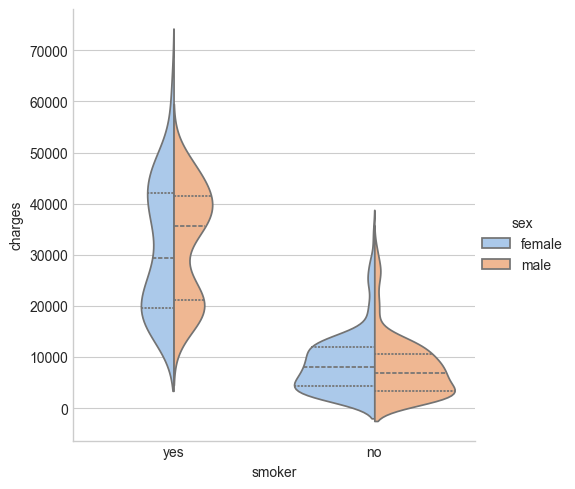

In [40]:
sns.catplot(x="smoker", y="charges", hue="sex",
            kind="violin", inner="quartiles", split=True,
            palette="pastel", data=data);

In [41]:
data.groupby(['smoker', 'sex']).agg('count')['age']

smoker  sex   
no      female    414
        male      390
yes     female     81
        male      115
Name: age, dtype: int64

<Axes: xlabel='region', ylabel='count'>

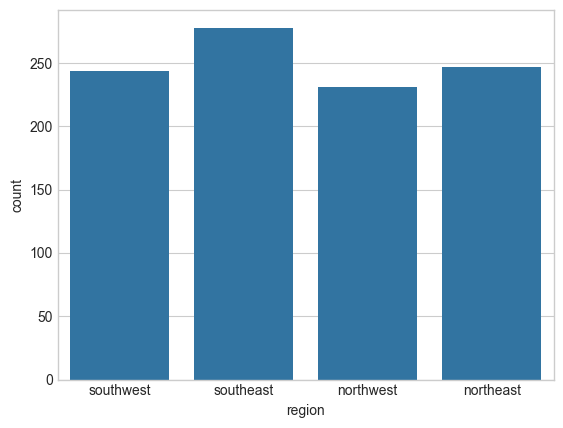

In [42]:
sns.countplot(x = 'region', data = data)

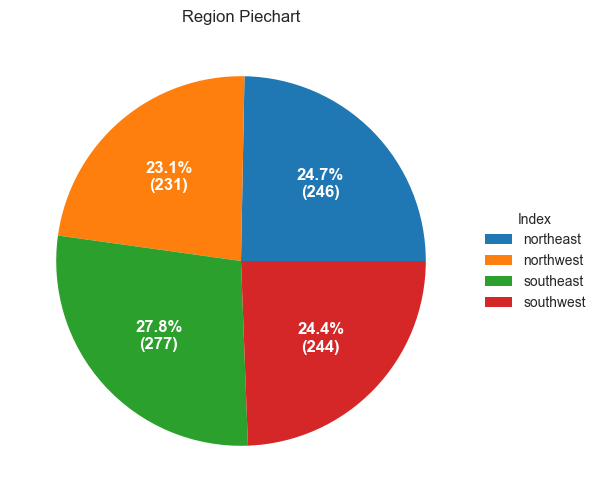

In [43]:
pie_chart('region')

<Axes: xlabel='children', ylabel='count'>

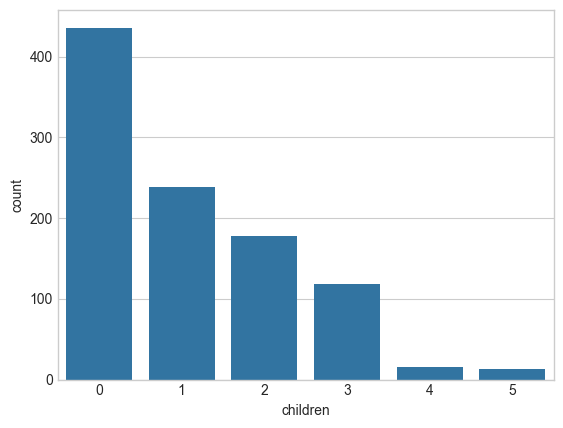

In [44]:
sns.countplot(x = 'children', data = data)

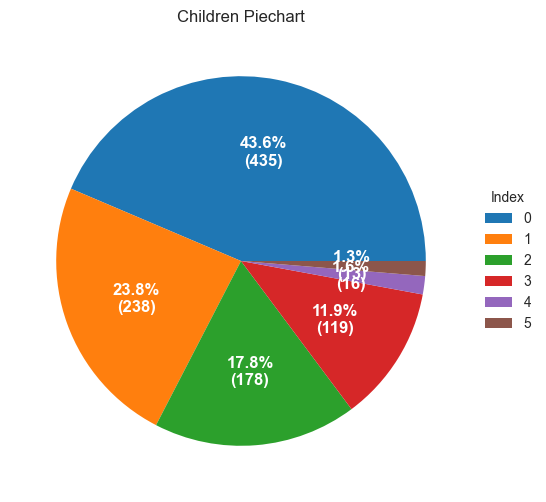

In [45]:
pie_chart('children')

In [46]:
data.groupby(['children']).agg('count')['age']

children
0    436
1    238
2    178
3    119
4     16
5     13
Name: age, dtype: int64

In [47]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [48]:
for x in ['sex', 'children', 'smoker', 'region']:
    data[x] = data[x].astype('category')

data.dtypes 

age            int64
sex         category
bmi          float64
children    category
smoker      category
region      category
charges      float64
dtype: object

In [49]:
type(data.dtypes)

pandas.Series

In [50]:

cat_columns = data.select_dtypes(['category']).columns
cat_columns

Index(['sex', 'children', 'smoker', 'region'], dtype='str')

In [51]:

data[cat_columns] = data[cat_columns].apply(lambda x: x.cat.codes)
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


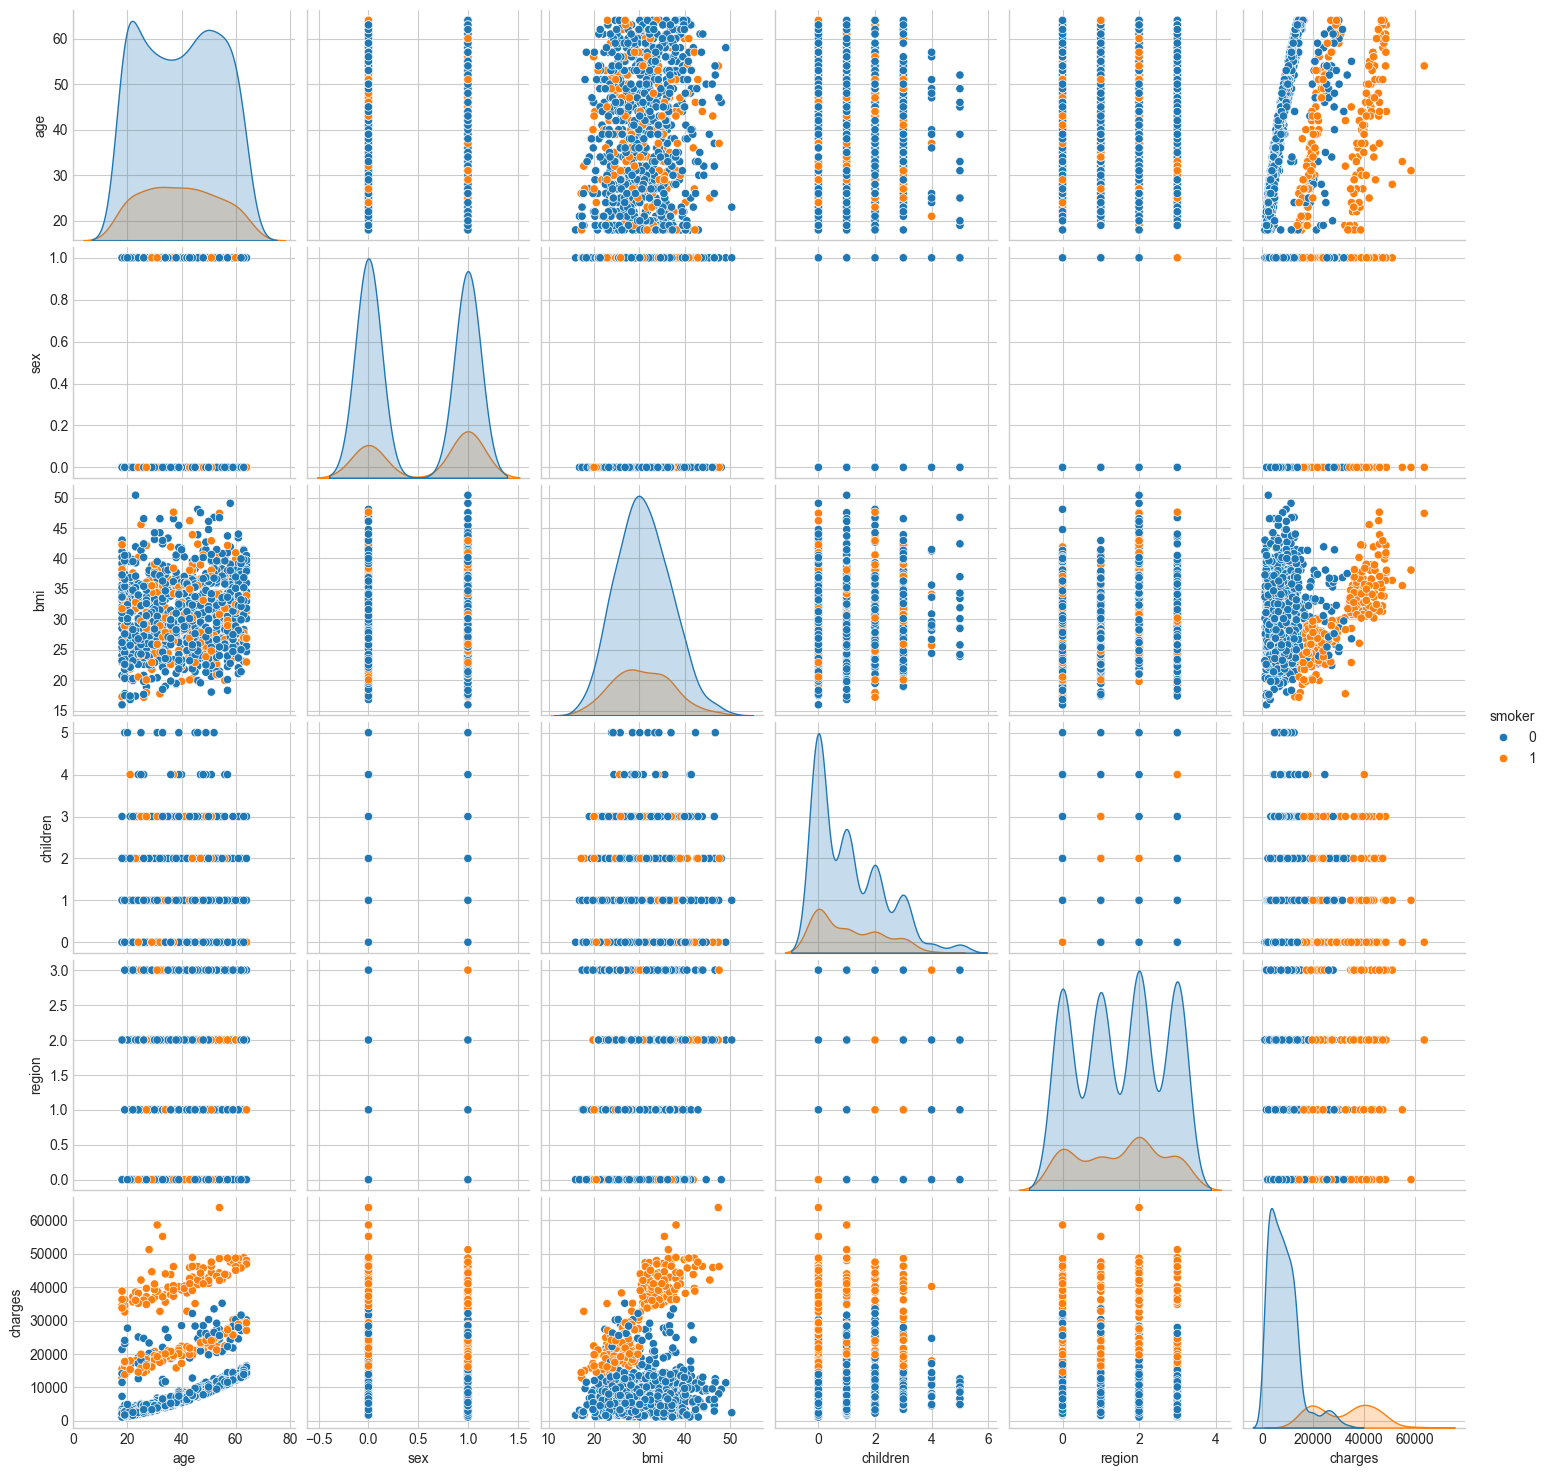

In [52]:

sns.pairplot(data, hue  = 'smoker')

##Relationship between Insurance Premium Charges, BMI and Smoking status (Smoker / Non - smoker) can be seen in this graph:

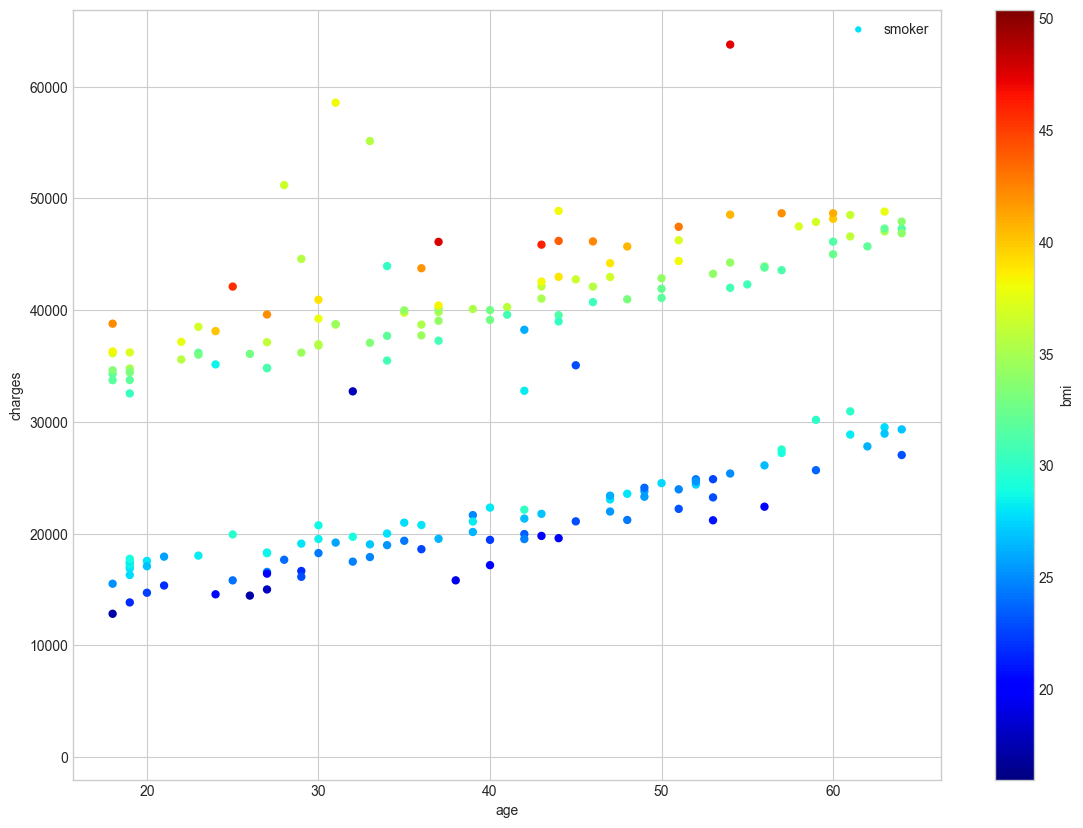

In [53]:
data.plot(kind="scatter", x="age", y="charges", 
    s=data["smoker"]*25, label="smoker", figsize=(14,10),
    c='bmi', cmap=plt.get_cmap("jet"), colorbar=True,
    sharex=False)
plt.legend()

<Axes: >

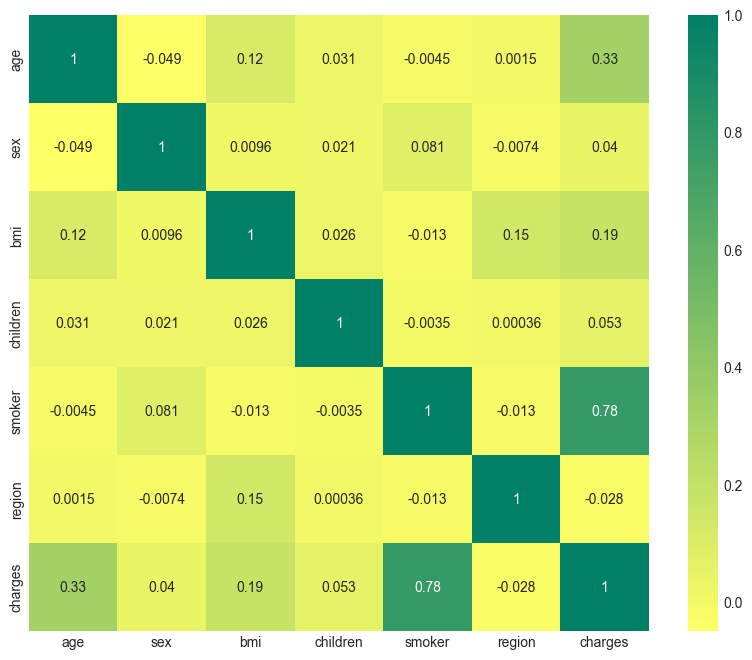

In [54]:
corr = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap = 'summer_r')

## 1 Do charges of people who smoke differ significantly from the people who don't?

In [55]:
smokers = data[data['smoker'] == 0]
nonsmokers = data[data['smoker'] == 1]
charge_smokers = smokers['charges']
charge_nonsmokers = nonsmokers['charges']

print(f'Number of smokers: {smokers.shape[0]}')
print(f'Variance in charges of smokers: {np.var(charge_smokers)}')
print(f'Number of non - smokers: {nonsmokers.shape[0]}')
print(f'Variance in charges of non - smokers: {np.var(charge_nonsmokers)}')

Number of smokers: 804
Variance in charges of smokers: 36382920.656370305
Number of non - smokers: 196
Variance in charges of non - smokers: 132371958.87244016


In [56]:
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(charge_smokers, charge_nonsmokers, equal_var=False)
print(f't_statistic: {t_statistic}\np_value: {p_value}')

t_statistic: -27.8206461214081
p_value: 2.987074080213112e-74


In [57]:
print ("two-sample t-test p-value=", p_value)

two-sample t-test p-value= 2.987074080213112e-74


In [58]:
p_value > 0.05

np.False_

In [59]:
smokers = data[data['smoker'] == 0]
nonsmokers = data[data['smoker'] == 1]
charge_smokers = smokers['charges']
charge_nonsmokers = nonsmokers['charges']

print(f'Number of smokers: {smokers.shape[0]}')
print(f'Variance in charges of smokers: {np.var(charge_smokers)}')
print(f'Number of non - smokers: {nonsmokers.shape[0]}')
print(f'Variance in charges of non - smokers: {np.var(charge_nonsmokers)}')

Number of smokers: 804
Variance in charges of smokers: 36382920.656370305
Number of non - smokers: 196
Variance in charges of non - smokers: 132371958.87244016


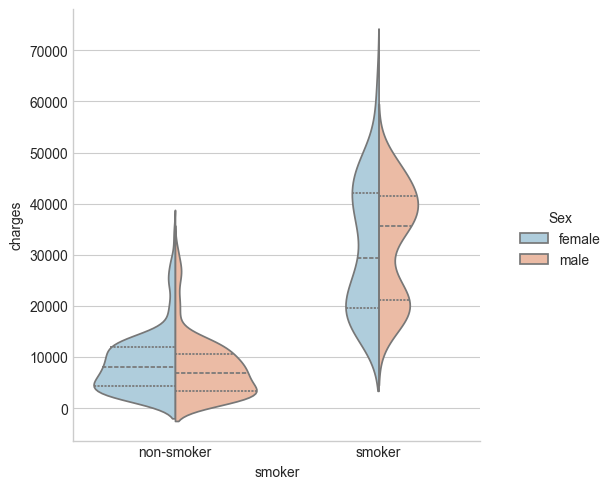

In [60]:
#Visualizing the collected data:
g = sns.catplot(x="smoker", y="charges", hue="sex",
            kind="violin", inner="quartiles", split=True,
            palette="RdBu_r", data=data, legend_out = True);

xlabels = ['non-smoker', 'smoker']
g.set_xticklabels(xlabels)

new_title = 'Sex'
g._legend.set_title(new_title)
g._legend.set_bbox_to_anchor([1.1, 0.5])
# replace labels
new_labels = ['female', 'male']
for t, l in zip(g._legend.texts, new_labels): t.set_text(l)

In [61]:
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(charge_smokers, charge_nonsmokers, equal_var=False)
print(f't_statistic: {t_statistic}\np_value: {p_value}')

t_statistic: -27.8206461214081
p_value: 2.987074080213112e-74


In [62]:
print ("two-sample t-test p-value=", p_value)

two-sample t-test p-value= 2.987074080213112e-74


In [63]:
p_value > 0.05

np.False_

BMI FOR MALE AND FEMALE:

In [64]:
males = data[data['sex'] == 1]
females = data[data['sex'] == 0]
bmi_males = males['bmi']
bmi_females = females['bmi']

print(f'Number of males: {males.shape[0]}')
print(f'Variance in BMI of males: {np.var(bmi_males)}')
print(f'Number of females: {females.shape[0]}')
print(f'Variance in BMI of females: {np.var(bmi_females)}')

Number of males: 505
Variance in BMI of males: 36.33213735653367
Number of females: 495
Variance in BMI of females: 36.73502368431793


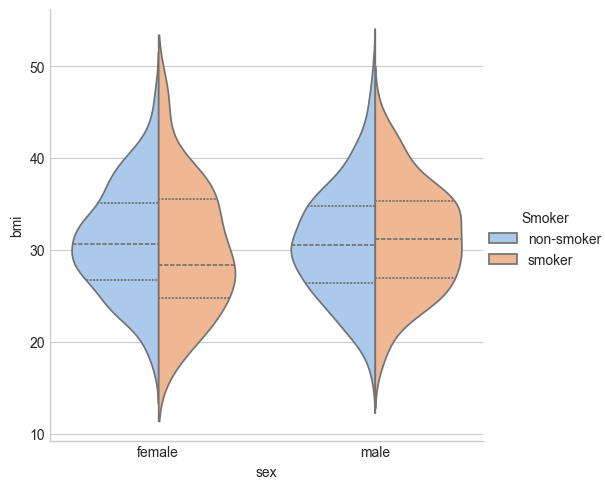

In [65]:

g = sns.catplot(x="sex", y="bmi", hue="smoker",
            kind="violin", inner="quartiles", split=True,
            palette="pastel", data=data, legend_out = True);

xlabels = ['female', 'male']
g.set_xticklabels(xlabels)

new_title = 'Smoker'
g._legend.set_title(new_title)
g._legend.set_bbox_to_anchor([1.1, 0.5])

new_labels = ['non-smoker', 'smoker']
for t, l in zip(g._legend.texts, new_labels): t.set_text(l)

In [66]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [67]:
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(bmi_males, bmi_females, equal_var=False)
print(f't_statistic: {t_statistic}\np_value: {p_value}')

t_statistic: 0.3046975974954142
p_value: 0.7606600478344813


In [68]:
print ("two-sample t-test p-value=", p_value)

two-sample t-test p-value= 0.7606600478344813


In [69]:
p_value > 0.05

np.True_

In [70]:
n_females = data['sex'].value_counts()[0] # number of females in the data
n_males = data['sex'].value_counts()[1] # number of females in the data

female_smokers = data[data['sex'] == 0].smoker.value_counts()[1] # number of female smokers
male_smokers = data[data['sex'] == 1].smoker.value_counts()[1] # number of male smokers

print([female_smokers, male_smokers] , [n_females, n_males])
print(f' Proportion of smokers in females, males = {round(115/662,4)*100}%, {round(159/676,4)*100}% respectively.')

[np.int64(81), np.int64(115)] [np.int64(495), np.int64(505)]
 Proportion of smokers in females, males = 17.37%, 23.52% respectively.


[Text(0, 0, 'female'), Text(0, 1, 'male')]

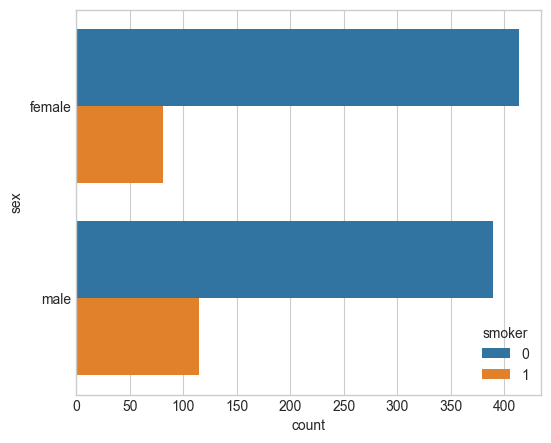

In [71]:
# Visualization of the collected data:
plt.figure(figsize=(6,5))
chart = sns.countplot(y = 'sex', hue = 'smoker', data = data)
chart.set_yticklabels(['female', 'male'])

In [72]:
!pip install statsmodels


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
from statsmodels.stats.proportion import proportions_ztest

stat, pval = proportions_ztest([female_smokers, male_smokers] , [n_females, n_males])
print(f'Statistic: {stat}\np_value: {pval}')

Statistic: -2.5524554054833026
p_value: 0.010696660183853788


In [74]:
if pval < 0.05:
    print(f'With a p-value of {pval} the difference is significant. We reject the Null Hypothesis.')
else:
    print(f'With a p-value of {pval} the difference is not significant. We fail to reject the Null Hypothesis')

With a p-value of 0.010696660183853788 the difference is significant. We reject the Null Hypothesis.


In [75]:
df = data[data['children'] <= 2]
female = df[df['sex'] == 0]
female.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.90,0,1,3,16884.92400
5,31,0,25.74,0,0,2,3756.62160
6,46,0,33.44,1,0,2,8240.58960
9,60,0,25.84,0,0,1,28923.13692
11,62,0,26.29,0,1,2,27808.72510


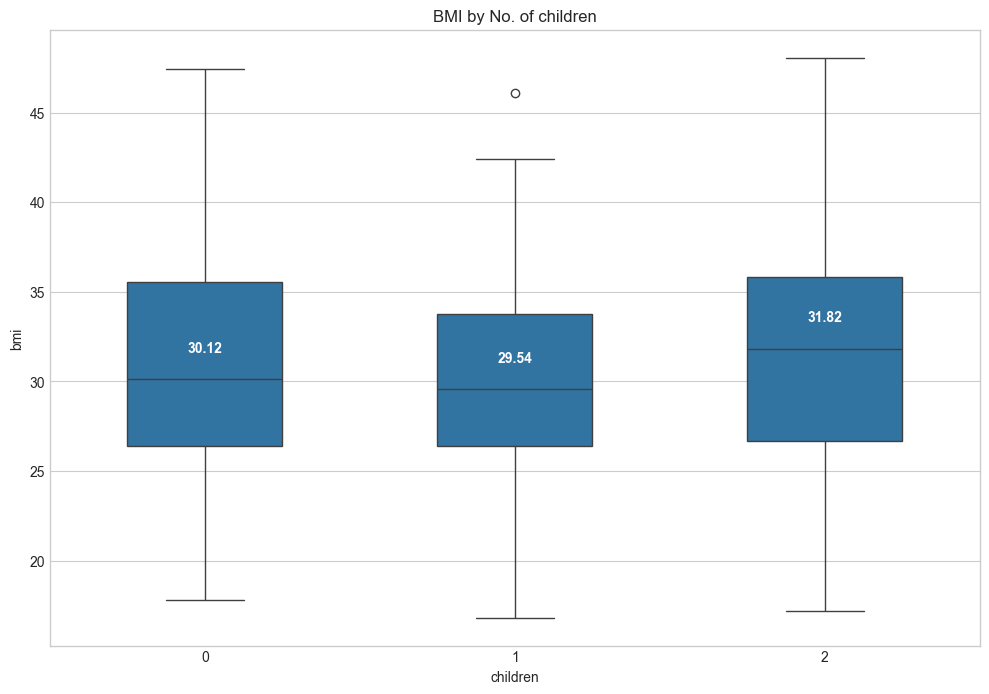

In [76]:

fig = plt.figure(figsize=(12, 8))
box_plot = sns.boxplot(x = "children", y = "bmi", data = female, width = 0.5)

medians = female.groupby(['children'])['bmi'].median().round(2)
vertical_offset = female['bmi'].median() * 0.05 # offset from median for display

medians
for xtick in box_plot.get_xticks():
    box_plot.text(xtick, medians[xtick] + vertical_offset,medians[xtick], 
            horizontalalignment='center',color='w',weight='semibold')


plt.title('BMI by No. of children')
plt.show()

In [77]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
print(pairwise_tukeyhsd(female['bmi'], female['children']))

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      1  -0.8876 0.4084 -2.5212  0.746  False
     0      2   0.4529 0.8226 -1.3357 2.2415  False
     1      2   1.3405  0.255 -0.6538 3.3348  False
---------------------------------------------------
